In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Step 2: Load dataset
# Replace with your dataset path
df = pd.read_csv("IPBA Dataset - NEW IPBA_BYOP DATASET.csv")

In [4]:
# Quick look
print(df.head())
print(df.info())


   Customer ID  Age Gender Item Purchased  Category Purchase \nAmount (USD)  \
0            1   55   Male         Blouse  Clothing                  $53.00   
1            2   19   Male        Sweater  Clothing                  $64.00   
2            3   50   Male          Jeans  Clothing                  $73.00   
3            4   21   Male        Sandals  Footwear                  $90.00   
4            5   45   Male         Blouse  Clothing                  $49.00   

        Location Size      Color  Season  ...  Frequency of\n Purchases  \
0       Kentucky    L       Gray  Winter  ...               Fortnightly   
1          Maine    L     Maroon  Winter  ...               Fortnightly   
2  Massachusetts    S     Maroon  Spring  ...                    Weekly   
3   Rhode Island    M     Maroon  Spring  ...                    Weekly   
4         Oregon    M  Turquoise  Spring  ...                  Annually   

  Previous Purchased \nAmount (USD) Average \nOrder Value (USD)  \
0      

In [6]:
print(df.describe())

       Customer ID          Age  Review \nRating  Previous\n Purchases  \
count  3900.000000  3900.000000      3900.000000           3900.000000   
mean   1950.500000    44.068462         3.749949             25.351538   
std    1125.977353    15.207589         0.716223             14.447125   
min       1.000000    18.000000         2.500000              1.000000   
25%     975.750000    31.000000         3.100000             13.000000   
50%    1950.500000    44.000000         3.700000             25.000000   
75%    2925.250000    57.000000         4.400000             38.000000   
max    3900.000000    70.000000         5.000000             50.000000   

       Time spend on website  Minutes      clicks   \
count                     3900.000000  3900.000000   
mean                        54.475641     0.999231   
std                         26.106872     0.820517   
min                         10.000000     0.000000   
25%                         31.000000     0.000000   
50%      

In [8]:
print(df.columns.tolist())

['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase \nAmount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review \nRating', 'Subscription \nStatus', 'Payment \nMethod', 'Shipping \nType', 'Discount \nApplied', 'Promo Code\n Used', 'Previous\n Purchases', 'Preferred Payment\n Method', 'Frequency of\n Purchases', 'Previous Purchased \nAmount (USD)', 'Average \nOrder Value (USD)', 'Total Sales \nRevenue Per Customer (USD)', 'Time spend on website  Minutes', ' clicks\xa0', 'total number of impressions', 'Click-through rate (CTR)', 'Website Traffic', 'Conversion\n Rate %']


In [9]:
# Clean column names
df.columns = df.columns.str.strip().str.replace("\n","_").str.replace(" ","_").str.replace(r"[^\w]", "", regex=True)

print(df.columns.tolist())

['Customer_ID', 'Age', 'Gender', 'Item_Purchased', 'Category', 'Purchase__Amount_USD', 'Location', 'Size', 'Color', 'Season', 'Review__Rating', 'Subscription__Status', 'Payment__Method', 'Shipping__Type', 'Discount__Applied', 'Promo_Code__Used', 'Previous__Purchases', 'Preferred_Payment__Method', 'Frequency_of__Purchases', 'Previous_Purchased__Amount_USD', 'Average__Order_Value_USD', 'Total_Sales__Revenue_Per_Customer_USD', 'Time_spend_on_website__Minutes', 'clicks', 'total_number_of_impressions', 'Clickthrough_rate_CTR', 'Website_Traffic', 'Conversion__Rate_']


In [14]:
# Convert numeric columns to numeric (coerce errors → NaN)
numeric_cols = [
    'Age','Purchase__Amount_USD','Previous_Purchased__Amount_USD',
    'Average__Order_Value_USD','Total_Sales__Revenue_Per_Customer_USD',
    'Time_spend_on_website__Minutes','clicks','total_number_of_impressions',
    'Clickthrough_rate_CTR','Website_Traffic','Conversion__Rate_'
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [15]:
# Feature engineering
df['TotalSpend'] = df['Purchase__Amount_USD'].fillna(0) + df['Previous_Purchased__Amount_USD'].fillna(0)
df['Engagement'] = df['clicks'].fillna(0) / (df['total_number_of_impressions'].fillna(0) + 1)
df['RevenuePerCustomer'] = df['Total_Sales__Revenue_Per_Customer_USD']
df['AvgOrderValue'] = df['Average__Order_Value_USD']
df['Frequency'] = df['Frequency_of__Purchases']
df['TimeOnSite'] = df['Time_spend_on_website__Minutes']

In [17]:
print(df.dtypes)


Customer_ID                                int64
Age                                        int64
Gender                                       str
Item_Purchased                               str
Category                                     str
Purchase__Amount_USD                     float64
Location                                     str
Size                                         str
Color                                        str
Season                                       str
Review__Rating                           float64
Subscription__Status                         str
Payment__Method                              str
Shipping__Type                               str
Discount__Applied                            str
Promo_Code__Used                             str
Previous__Purchases                        int64
Preferred_Payment__Method                    str
Frequency_of__Purchases                      str
Previous_Purchased__Amount_USD           float64
Average__Order_Value

In [18]:
# Convert Frequency_of__Purchases to numeric
df['Frequency_of__Purchases'] = pd.to_numeric(df['Frequency_of__Purchases'], errors='coerce')

# Recreate Frequency column as numeric
df['Frequency'] = df['Frequency_of__Purchases']


In [19]:
# Numeric aggregation
numeric_cols = [
    'Age','TotalSpend','Frequency','AvgOrderValue',
    'RevenuePerCustomer','Engagement','TimeOnSite','Conversion__Rate_'
]

numeric_agg = df.groupby('Customer_ID')[numeric_cols].mean().reset_index()

# Categorical aggregation (Gender mode)
gender_mode = df.groupby('Customer_ID')['Gender'].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()

# Merge numeric + categorical
customer_df = pd.merge(numeric_agg, gender_mode, on='Customer_ID')


In [20]:
# --- Categorical aggregation (mode for Gender) ---
gender_mode = df.groupby('Customer_ID')['Gender'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).reset_index()

In [21]:
# --- Merge numeric + categorical ---
customer_df = pd.merge(numeric_agg, gender_mode, on='Customer_ID')

In [25]:
# --- Prepare features for clustering ---
numeric_features = [
    'Age','TotalSpend','Frequency','AvgOrderValue',
    'RevenuePerCustomer','Engagement','TimeOnSite','Conversion__Rate_'
]

X = customer_df[numeric_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


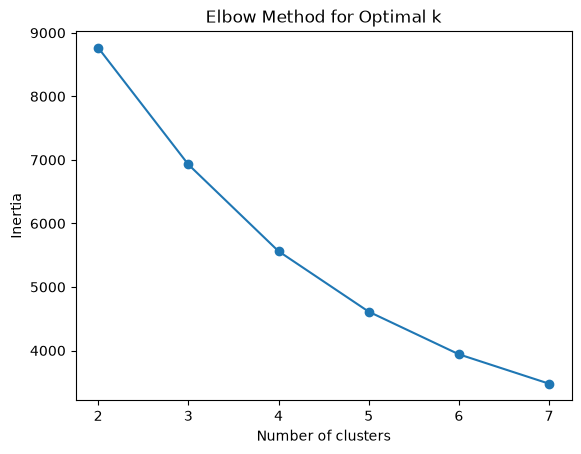

In [26]:
# Elbow Method
inertia = []
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,8), inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [27]:
# Fit KMeans (example: k=4)
kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)


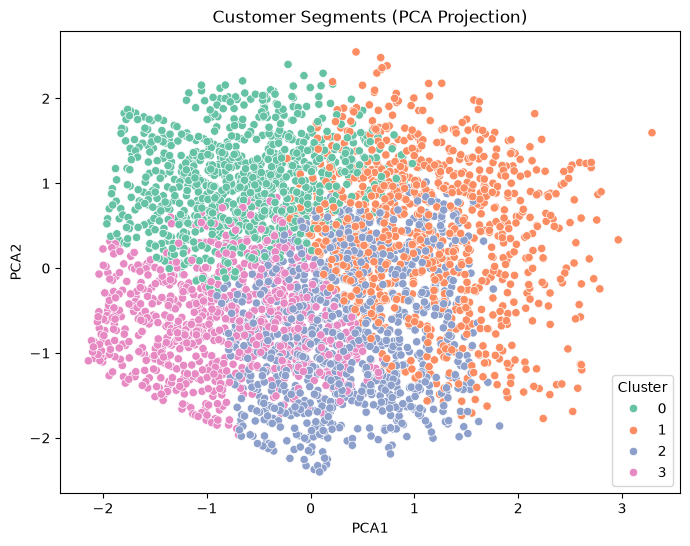

In [29]:
# --- PCA Visualization ---
from sklearn.decomposition import PCA   # <-- make sure this import is present

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

customer_df['PCA1'] = pca_result[:,0]
customer_df['PCA2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=customer_df, palette='Set2')
plt.title("Customer Segments (PCA Projection)")
plt.show()


In [30]:
# Cluster Profiling
cluster_profile = customer_df.groupby('Cluster')[numeric_features].mean()
print(cluster_profile)

               Age  TotalSpend  Frequency  AvgOrderValue  RevenuePerCustomer  \
Cluster                                                                        
0        58.508163         0.0        NaN            NaN                 NaN   
1        47.420106         0.0        NaN            NaN                 NaN   
2        40.343691         0.0        NaN            NaN                 NaN   
3        29.432640         0.0        NaN            NaN                 NaN   

         Engagement  TimeOnSite  Conversion__Rate_  
Cluster                                             
0          0.002469   71.036735                NaN  
1          0.009082   48.791534                NaN  
2          0.002405   26.875706                NaN  
3          0.003222   74.686747                NaN  


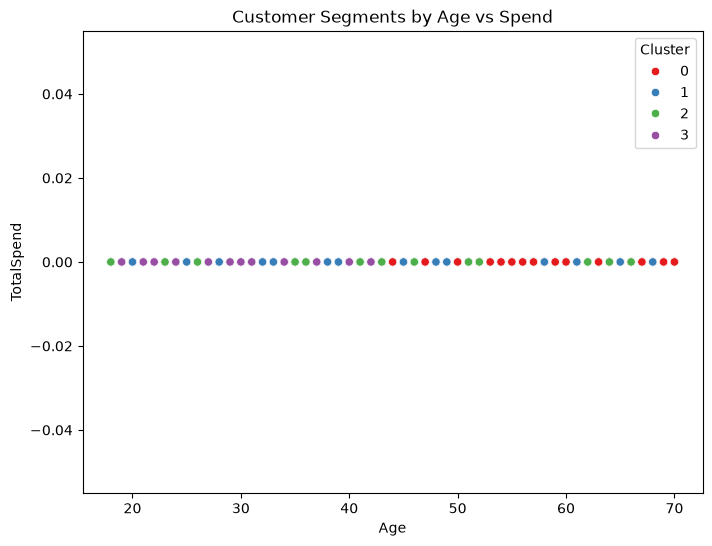

In [31]:
# Extra Visualization: Age vs Spend
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age', y='TotalSpend', hue='Cluster', data=customer_df, palette='Set1')
plt.title("Customer Segments by Age vs Spend")
plt.show()

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
print(customer_df[['Frequency','RevenuePerCustomer','Cluster']].dtypes)
